Question 1: What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.  

Ans: Anomaly detection identifies rare outlying data points or observations that significantly deviate from normal patterns. It is used in machine learning to flag outliers in datasets which in turn enables proactive responses.  
Types of Anomalies:   
Point Anomalies occur when a single datapoint acts very much different from the rest. Eg: A sudden credit card transaction of Rs. 10000 amongst general Rs. 50 transactions.  
Contextual Anomalies are are unusual only related to a specific context like particular time or location. Eg: High server usage at 3A.M. when generally traffic is low.  
Collective anomalies involve groups of data points that appear abnormal together. Eg: Multiple failed login attempts in a short time using IPs from around the world.


Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.  

Ans:Isolation forest creates random ttrees to isolate data points. The anomalies require fewer splits as they are sparse. Hence it is tree based and efficient. Isolation Forest suits high dimensional data like fraud detection and network intrusion where speed is more important than the cluster shape.    

DBSACAN clusters dense data regions via density-reachability, the points outside the clusters are outliers. DBSCAN works for spatial data with noise, such as geographic outliers or image segmentation anomalies.   
 
Local Outlier Factor computes local density deviation, which is a points outlier score that reflects how much its neighborhood density differs from its neighbours, in turn capturing the local anomalies. LOF excels in datasets with varying densities, like manufacturing defects amid clustered normals or local fraud patterns.  

Question 3: What are the key components of a Time Series? Explain each with one
example.  

Ans: The key components of a time series are:  
1. Level: Baseline value around which other patterns oscillate (average position).
Example: Steady baseline temperature of 25°C in a city, before daily/seasonal swings.
2. Trend: The long-term increase, decrease, or stability in data values, smoothing out short-term fluctuations.
Example: Rising global temperatures over decades due to climate change.
3. Seasonality: Regular, repeating patterns at fixed intervals, like daily, monthly, or yearly cycles.
Example: Higher ice cream sales every summer due to warmer weather.
4. CycliCITY:Fluctuations over longer, irregular periods without a fixed frequency, often tied to economic or business cycles.
Example: GDP growth followed by recessions every 5-10 years.
5. Noise: Random noise or unpredictable variations after removing other components, caused by measurement errors or sudden events.
Example: A brief sales spike from an unexpected holiday promotion.

Question 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?  

Ans: In time series, a process is stationary if its key statistical properties (mean, variance, and autocovariance/autocorrelation structure) do not change over time. In practice, this means no systematic trend or changing seasonality, the series looks the same at any time shift.    

How do we test for stationarity? We use 3 main approaches:

Visual inspection - Plot the raw series. Does it trend up/down? Does the spread widen/narrow over time? Plot rolling mean (moving average) and rolling std dev—if they drift, it's non-stationary.

ACF plot - Autocorrelation function. Stationary data's ACF drops quickly to zero. Slow decay = likely trend/unit root problem.  

Statistical tests:
ADF test (Augmented Dickey-Fuller): Tests if there's a unit root. Null = non-stationary. p-value < 0.05 → stationary.
KPSS test: Opposite null (stationary). p-value > 0.05 → stationary. We run both for confirmation.

Transforming non-stationary to stationary series:

1. Differencing (most common):
Subtract each value from the previous one: y[t] - y[t-1].
If still non-stationary, second difference: y[t] - 2*y[t-1] + y[t-2].
2. Seasonal differencing:
Subtract from same season last period: y[t] - y[t-12] (monthly data).
3. Log transformation (stabilizes variance):
log(y[t]) for positive data with increasing variance.
4. Detrending: Fit a trend line (linear/polynomial) and subtract it.
5. Deseasonalizing: Use STL decomposition to remove seasonal component.

Our typical workflow:  
Plot + rolling stats → visual check  
ADF test → if fail, difference once  
Re-test ADF on differences  
Check ACF → if seasonal pattern remains, seasonal difference  
Log if variance issue  
Final ADF/KPSS → stationary!

Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.   

Ans: 
1. AR (AutoRegressive) - Order p: AR(p)
Structure: Current value depends only on its own past values (lags).
Formula: y[t] = c + φ₁*y[t-1] + φ₂*y[t-2] + ... + φₚ*y[t-p] + ε[t]

φ = autoregressive coefficients

ε = random error (white noise)

What it captures: Momentum/patterns from previous values.
Example: Daily temperatures where today's temp depends on yesterday's and day-before's.
Use case: Stock prices with short-term momentum (no trend/seasonality).
Limitation: Assumes stationarity; fails on trending data.

2. MA (Moving Average) - Order q: MA(q)
Structure: Current value depends on past forecast errors/residuals.
Formula: y[t] = c + ε[t] + θ₁*ε[t-1] + θ₂*ε[t-2] + ... + θq*ε[t-q]

θ = moving average coefficients

What it captures: Short-term 'shocks' or error corrections.
Example: Call center volume where spikes/dips echo 1-2 days (error from forecast).
Use case: Irregular short-term fluctuations (noise-heavy data).
Limitation: Only captures error patterns, not value patterns.

3. ARMA (AR + MA) - Orders p,q: ARMA(p,q)
Structure: Combines AR + MA: AR(p) + MA(q).
Formula: Full combo of both above.

What it captures: Both past values AND past errors.
Example: Stable economic indicator (CPI) with momentum + occasional shocks.
Use case: Stationary data without trend/seasonality.
Limitation: Fails if data has trend (drifts away).

4. ARIMA (AR + I + MA) - Orders p,d,q: ARIMA(p,d,q)
Structure: ARMA + Integrated (I): automatically differences data 'd' times to remove trend.
Formula: Fit ARMA on d-times-differenced series, then reverse.

What it captures: Trends via differencing + ARMA patterns.
Example: Airline passengers (trending up) → difference once → stationary → ARMA.
Use case: Non-stationary data with trend but no seasonality (sales, GDP).
Key: d=1 (first difference) for linear trend; d=2 for quadratic.

5. SARIMA (Seasonal ARIMA) - Orders (p,d,q)(P,D,Q)s
Structure: ARIMA + Seasonal components at period s (12=monthly, 7=weekly).
Full notation: (p,d,q)×(P,D,Q)s

(p,d,q) = non-seasonal

(P,D,Q) = seasonal AR/MA/differencing

s = seasonal length

What it captures: Trends + seasonality.
Example: Monthly sales peaking Dec → (1,1,1)(1,1,1)12.
Use case: Holiday sales, electricity demand (strong yearly cycles).

6. SARIMAX (Seasonal ARIMA + eXogenous)
Structure: SARIMA + external predictor variables (X).
Formula: SARIMA + β₁*X₁[t] + β₂*X₂[t] + ...

What it captures: Everything SARIMA does + external factors.
Example: Sales forecast using SARIMA(seasonality) + weather, promotions, competitor_price.
Use case: When domain knowledge gives predictors (marketing spend, holidays as dummies).

Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components.

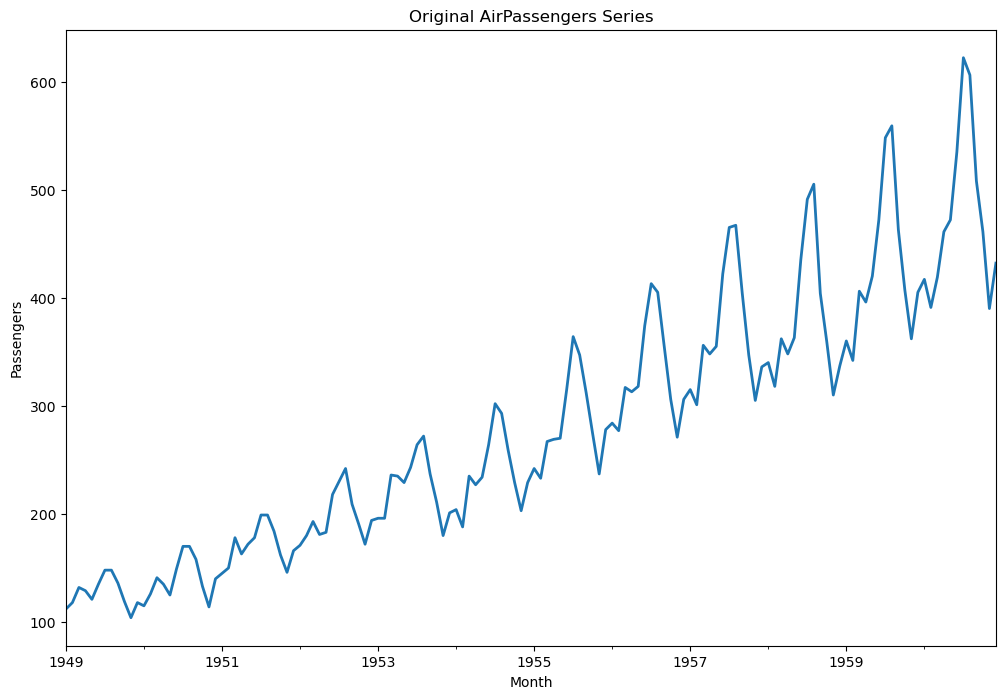

<Figure size 1200x800 with 0 Axes>

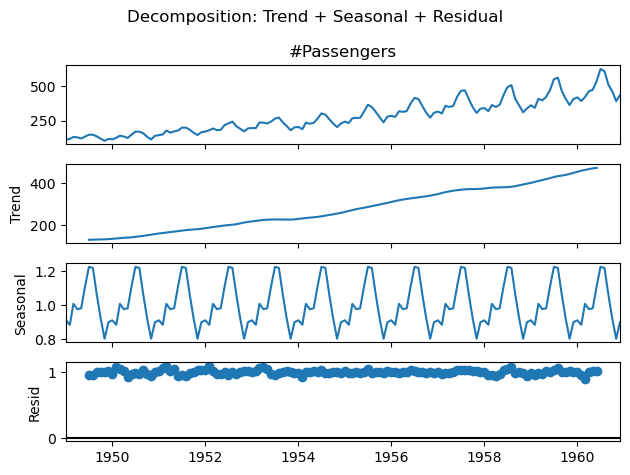

In [1]:
from calendar import Month

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('AirPassengers.csv')
df['Month']=pd.to_datetime(df['Month'])
ts=df.set_index('Month')['#Passengers']

#Plottng Original series
plt.figure(figsize=(12,8))
ts.plot(title='Original AirPassengers Series', linewidth=2)
plt.ylabel('Passengers')

#decompose
decomp = seasonal_decompose(ts, model='multiplicative', period=12)

#plotting Trend, Seasonality and Residual
plt.figure(figsize=(12,8))
decomp.plot()
plt.suptitle('Decomposition: Trend + Seasonal + Residual')
plt.tight_layout()

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot.

C:\Users\Tatha\AppData\Local\Temp\ipykernel_96104\3357687729.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('NYC_taxi_fare_data.csv')


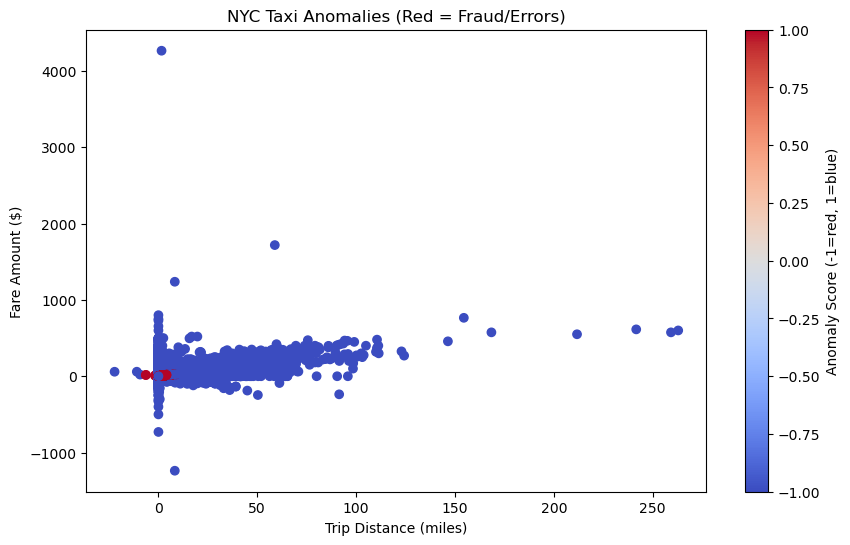

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
df=pd.read_csv('NYC_taxi_fare_data.csv')
df=df.dropna()
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])
numeric_cols = ['fare_amount', 'trip_distance', 'passenger_count', 'total_amount', 
                'extra', 'mta_tax', 'tip_amount', 'tolls_amount']
X = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
out = IsolationForest(contamination=0.2,random_state=42)
out.fit(X_scaled)
anomaly_labels=out.predict(X_scaled)
plt.figure(figsize=(10,6))
plt.scatter(X['trip_distance'], X['fare_amount'], 
           c=anomaly_labels, cmap='coolwarm')
plt.colorbar(label='Anomaly Score (-1=red, 1=blue)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.title('NYC Taxi Anomalies (Red = Fraud/Errors)')
plt.show()

Question 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.

c:\Users\Tatha\anaconda3\envs\pwskills\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tatha\anaconda3\envs\pwskills\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


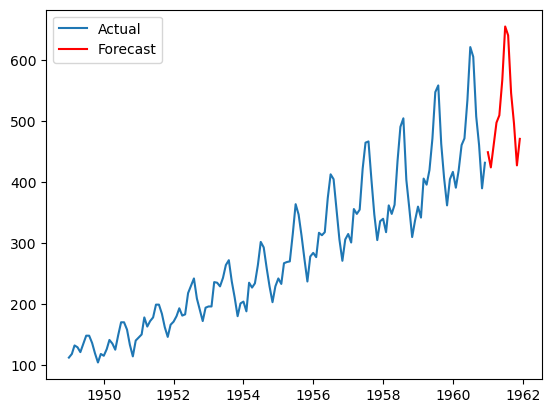

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
df = pd.read_csv('AirPassengers.csv')
df['Month']=pd.to_datetime(df['Month'])
ts=df.set_index('Month')['#Passengers']
model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12))
fitted_model = model.fit()
forecast = fitted_model.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
dates = pd.date_range(start=ts.index[-1]+pd.DateOffset(months=1), periods=12, freq='MS')
plt.plot(ts, label='Actual')
plt.plot(dates, forecast_mean, label='Forecast', color='red')  # Just THIS line
plt.legend()
plt.show()

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.

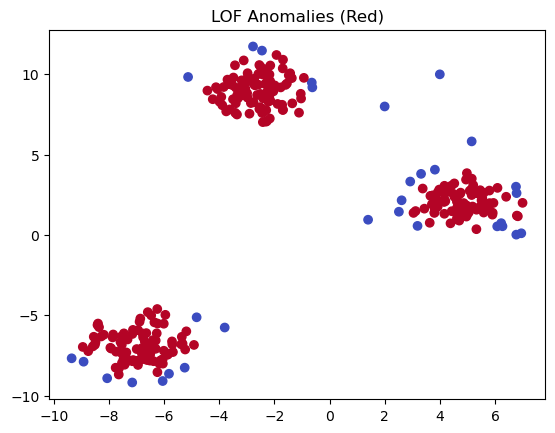

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs
X, _ = make_blobs(300, random_state=42)
X = np.vstack([X, [[2,8],[7,2],[4,10]]])
lof = LocalOutlierFactor(contamination=0.1)
labels = lof.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels, cmap='coolwarm')
plt.title('LOF Anomalies (Red)')
plt.show()

Question 10: You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.  
Explain your real-time data science workflow:  
● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?  
● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?  
● How would you validate and monitor the performance over time?  
● How would this solution help business decisions or operations?  


Ans: 
1. Anomaly Detection: Isolation Forest  
Fastest for streaming (O(n)), incremental updates  
Features: energy_usage, temp, humidity (15-min windows)  

2. Forecasting: SARIMAX  
SARIMAX(2,1,2)(1,1,1)96 + weather covariates  
15-min - 1hr ahead forecasts  

3. Validation/Monitoring:  MAPE <5%, Anomaly F1>0.85  
KS-test for drift detection  and Dashboards for overtime.

4. Business Decisions/Operations: Prevent outages, Dynamic pricing, Capacity optimization, Fraud detection.